# Punto 2 Duque & Becerra Consulting

## Imports y configuración

In [75]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel


sns.set_theme(style="whitegrid")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    mean_absolute_error
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from xgboost import XGBRegressor
SCORING_MAIN = "f1"
import joblib
import pickle

## Exploración y preprocesamiento

La estrategia de imputación se diseñó teniendo en cuenta que la base es un panel de países
observado entre 2000 y 2015. Por ello, priorizamos métodos que aprovecharan la estructura
longitudinal y la heterogeneidad entre países. En primer lugar, imputamos varias covariables
mediante interpolación lineal dentro de cada país, usando años vecinos, lo cual resulta
apropiado para variables que evolucionan de manera relativamente suave en el tiempo, como
escolaridad, PIB o vacunación. En segundo lugar, para faltantes que no podían recuperarse
por trayectoria temporal, utilizamos imputación por regresión con variables sanitarias y
socioeconómicas relacionadas, preservando así relaciones económicas plausibles entre
ingreso, salud y capital humano. Finalmente, solo en un número reducido de casos residuales
usamos imputación por media como mecanismo de respaldo. Esta estrategia es adecuada en
datos panel porque aprovecha la dimensión temporal, evita tratar observaciones país-año
como casos independientes y conserva mejor la heterogeneidad estructural de la muestra.


In [3]:
df = pd.read_csv("/Users/juanfelipe/Documents/Datos_Taller1/Punto2/Life Expectancy Data.csv")

df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.dtypes

Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [5]:
dfna = df.isna().sum()
dfna

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [6]:
df_completo = df[df['Schooling'].notna()].copy()
df_missing  = df[df['Schooling'].isna()].copy()

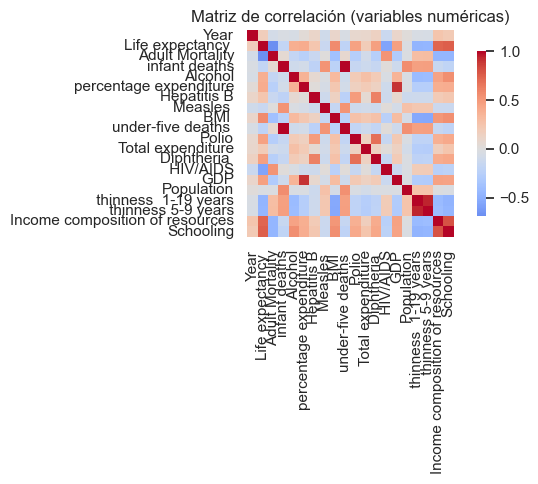

Top correlaciones con el target:


Year                               1.000000
Income composition of resources    0.243468
Schooling                          0.209400
Life expectancy                    0.171042
Diphtheria                         0.138577
 HIV/AIDS                         -0.137533
Hepatitis B                        0.107726
 BMI                               0.104698
GDP                                0.102615
Measles                           -0.092557
Name: Year, dtype: float64

In [7]:
numeric_cols = df_completo.select_dtypes(include=["number"]).columns
corr = df_completo[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

# Intento simple de detectar el target para mostrar correlaciones
candidates = [
    c for c in numeric_cols
    if any(k in c.lower() for k in ["Life expectancy", "", "value", "precio", "valor"])
]
if candidates:
    target_for_corr = candidates[0]
    corr_target = corr[target_for_corr].sort_values(key=lambda s: s.abs(), ascending=False)
    print("Top correlaciones con el target:")
    display(corr_target.head(10))
else:
    print("No se detectó target para correlaciones. Puedes definir TARGET más abajo.")

In [8]:
variables = ['Income composition of resources', 'GDP', ' BMI ', ' HIV/AIDS', 'Schooling']
print(df[variables].isna().sum().sort_values())

 HIV/AIDS                            0
 BMI                                34
Schooling                          163
Income composition of resources    167
GDP                                448
dtype: int64


In [9]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')

In [10]:

print(df[[' BMI ', ' HIV/AIDS', 'Life expectancy ', 'Adult Mortality']].corr()[' BMI '].sort_values())

Adult Mortality    -0.387017
 HIV/AIDS          -0.243717
Life expectancy     0.567694
 BMI                1.000000
Name:  BMI , dtype: float64


In [11]:
def imputar_por_regresion(df, target, predictores):
    mask_predictores_ok = df[predictores].notna().all(axis=1)
    df_completo = df[mask_predictores_ok & df[target].notna()].copy()
    df_missing  = df[mask_predictores_ok & df[target].isna()].copy()
    if len(df_missing) == 0:
        print(f"  {target}: sin missings")
        return df
    modelo = LinearRegression()
    modelo.fit(df_completo[predictores], df_completo[target])
    df.loc[df_missing.index, target] = modelo.predict(df_missing[predictores])
    print(f"  {target}: {len(df_missing)} imputados | R² = {modelo.score(df_completo[predictores], df_completo[target]):.3f}")
    return df

In [12]:
df.isna().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [13]:
df = df.drop(columns=['Population'])

In [14]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [15]:
vars_imputar = ['Alcohol', 'Total expenditure', 'Hepatitis B', 'GDP']

for var in vars_imputar:
    # Interpolación lineal dentro de cada país (usa años cercanos)
    df[var] = df.groupby('Country')[var].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

print("\nMissings tras interpolación por país:")
print(df[vars_imputar].isna().sum())


Missings tras interpolación por país:
Alcohol               17
Total expenditure     32
Hepatitis B          144
GDP                  405
dtype: int64


In [16]:
print(df.isna().sum().sort_values(ascending=False))

GDP                                405
Income composition of resources    167
Schooling                          163
Hepatitis B                        144
thinness 5-9 years                  34
thinness  1-19 years                34
BMI                                 34
Total expenditure                   32
Polio                               19
Diphtheria                          19
Alcohol                             17
Adult Mortality                     10
Life expectancy                     10
percentage expenditure               0
Measles                              0
Year                                 0
under-five deaths                    0
HIV/AIDS                             0
infant deaths                        0
Status                               0
Country                              0
dtype: int64


In [17]:
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,83,6.0,8.16,65.0,0.1,584.259210,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,86,58.0,8.18,62.0,0.1,612.696514,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,89,62.0,8.13,64.0,0.1,631.744976,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,93,67.0,8.52,67.0,0.1,669.959000,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,97,68.0,7.87,68.0,0.1,63.537231,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,42,67.0,7.13,65.0,33.6,454.366654,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,41,7.0,6.52,68.0,36.7,453.351155,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,40,73.0,6.53,71.0,39.8,57.348340,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,39,76.0,6.16,75.0,42.1,548.587312,1.6,1.7,0.427,9.8


In [18]:
vars_interpolar = ['BMI', 'Alcohol', 'Total expenditure', 'Hepatitis B', 
                   'GDP', 'Income composition of resources', 'Schooling',
                   'thinness  1-19 years', 'thinness 5-9 years', 
                   'Polio', 'Diphtheria']

In [19]:
df = df.sort_values(['Country', 'Year'])

In [20]:
for var in vars_interpolar:
    df[var] = df.groupby('Country')[var].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

In [21]:
print(df[vars_interpolar].isna().sum())

BMI                                 34
Alcohol                             17
Total expenditure                   32
Hepatitis B                        144
GDP                                405
Income composition of resources    167
Schooling                          163
thinness  1-19 years                34
thinness 5-9 years                  34
Polio                                0
Diphtheria                           0
dtype: int64


In [22]:
vars_media = ['Polio', 'Diphtheria', 'thinness  1-19 years', 'thinness 5-9 years']
for var in vars_media:
    df[var] = df[var].fillna(df[var].mean())
print("\nImputación por media lista ✓")


Imputación por media lista ✓


In [23]:
df = imputar_por_regresion(df,
    target      = 'BMI',
    predictores = ['HIV/AIDS', 'Adult Mortality'])

  BMI: 32 imputados | R² = 0.152


In [24]:
df = imputar_por_regresion(df,
    target      = 'BMI',
    predictores = ['HIV/AIDS', 'Adult Mortality'])

df = imputar_por_regresion(df,
    target      = 'Income composition of resources',
    predictores = ['HIV/AIDS', 'BMI', 'Adult Mortality'])

df = imputar_por_regresion(df,
    target      = 'Schooling',
    predictores = ['Income composition of resources', 'HIV/AIDS', 'BMI', 'Adult Mortality'])

df = imputar_por_regresion(df,
    target      = 'Alcohol',
    predictores = ['Income composition of resources', 'HIV/AIDS', 'Adult Mortality'])

df = imputar_por_regresion(df,
    target      = 'Total expenditure',
    predictores = ['Income composition of resources', 'HIV/AIDS', 'Adult Mortality', 'Alcohol'])

df = imputar_por_regresion(df,
    target      = 'Hepatitis B',
    predictores = ['Polio', 'Diphtheria', 'HIV/AIDS', 'Income composition of resources'])

df = imputar_por_regresion(df,
    target      = 'GDP',
    predictores = ['Income composition of resources', 'HIV/AIDS', 'Total expenditure', 'Adult Mortality'])

  BMI: sin missings
  Income composition of resources: 160 imputados | R² = 0.339
  Schooling: 160 imputados | R² = 0.674
  Alcohol: 16 imputados | R² = 0.207
  Total expenditure: 32 imputados | R² = 0.103
  Hepatitis B: 144 imputados | R² = 0.363
  GDP: 400 imputados | R² = 0.223


In [25]:
df['Life expectancy'] = df['Life expectancy'].fillna(df['Life expectancy'].mean())
df['Adult Mortality']  = df['Adult Mortality'].fillna(df['Adult Mortality'].mean())

In [26]:
print(df.isna().sum().sort_values(ascending=False))

Income composition of resources    7
GDP                                5
Schooling                          3
BMI                                2
Alcohol                            1
Adult Mortality                    0
Total expenditure                  0
Status                             0
thinness 5-9 years                 0
thinness  1-19 years               0
Life expectancy                    0
HIV/AIDS                           0
Diphtheria                         0
Polio                              0
infant deaths                      0
under-five deaths                  0
Year                               0
Measles                            0
Hepatitis B                        0
percentage expenditure             0
Country                            0
dtype: int64


In [27]:
vars_residuales = ['Income composition of resources', 'GDP', 'Schooling', 'BMI', 'Alcohol']

for var in vars_residuales:
    df[var] = df[var].fillna(df[var].mean())

# Verificación final
print(df.isna().sum().sort_values(ascending=False))

Country                            0
under-five deaths                  0
Income composition of resources    0
thinness 5-9 years                 0
thinness  1-19 years               0
GDP                                0
HIV/AIDS                           0
Diphtheria                         0
Total expenditure                  0
Polio                              0
BMI                                0
Year                               0
Measles                            0
Hepatitis B                        0
percentage expenditure             0
Alcohol                            0
infant deaths                      0
Adult Mortality                    0
Life expectancy                    0
Status                             0
Schooling                          0
dtype: int64


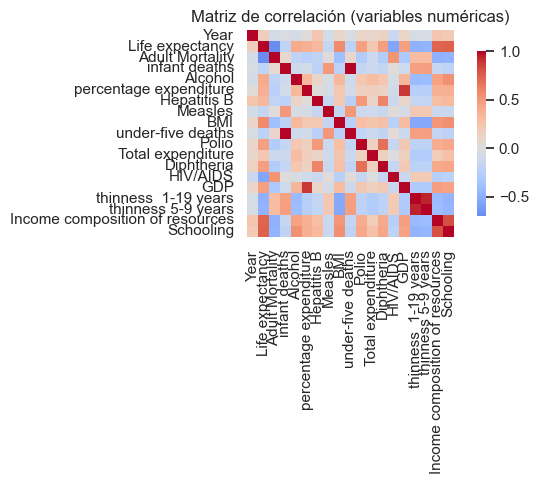

No se detectó target para correlaciones. Puedes definir TARGET más abajo.


In [28]:
numeric_cols = df.select_dtypes(include=["number"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

# Intento simple de detectar el target para mostrar correlaciones
candidates = [
    c for c in numeric_cols
    if any(k in c.lower() for k in ["price", "target", "value", "precio", "valor"])
]
if candidates:
    target_for_corr = candidates[0]
    corr_target = corr[target_for_corr].sort_values(key=lambda s: s.abs(), ascending=False)
    print("Top correlaciones con el target:")
    display(corr_target.head(10))
else:
    print("No se detectó target para correlaciones. Puedes definir TARGET más abajo.")

Sigue practicamente igual

In [29]:
TARGET = 'Life expectancy'
print("TARGET seleccionado:", TARGET)

TARGET seleccionado: Life expectancy


In [30]:
df = df.dropna(subset=[TARGET]).copy()

In [31]:

df['is_developing'] = (df['Status'] == 'Developing').astype(int)

df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,is_developing
15,Afghanistan,2000,Developing,54.8,321.0,88,0.01,10.424960,62.0,6532,...,24.0,8.20,24.0,0.1,114.560000,2.3,2.5,0.338,5.5,1
14,Afghanistan,2001,Developing,55.3,316.0,88,0.01,10.574728,63.0,8762,...,35.0,7.80,33.0,0.1,117.496980,2.1,2.4,0.340,5.9,1
13,Afghanistan,2002,Developing,56.2,3.0,88,0.01,16.887351,64.0,2486,...,36.0,7.76,36.0,0.1,187.845950,19.9,2.2,0.341,6.2,1
12,Afghanistan,2003,Developing,56.7,295.0,87,0.01,11.089053,65.0,798,...,41.0,8.82,41.0,0.1,198.728544,19.7,19.9,0.373,6.5,1
11,Afghanistan,2004,Developing,57.0,293.0,87,0.02,15.296066,67.0,466,...,5.0,8.79,5.0,0.1,219.141353,19.5,19.7,0.381,6.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,Zimbabwe,2011,Developing,54.9,464.0,28,6.00,63.750530,94.0,0,...,93.0,6.31,93.0,13.3,839.927936,6.8,6.7,0.452,10.1,1
2925,Zimbabwe,2012,Developing,56.6,429.0,26,6.09,92.602336,97.0,0,...,95.0,6.69,95.0,8.8,955.648466,6.5,6.4,0.464,9.8,1
2924,Zimbabwe,2013,Developing,58.0,399.0,25,6.39,10.666707,95.0,0,...,95.0,6.88,95.0,6.8,111.227396,6.2,6.0,0.488,10.4,1
2923,Zimbabwe,2014,Developing,59.2,371.0,23,6.50,10.822595,91.0,0,...,92.0,6.44,91.0,6.3,127.474620,5.9,5.7,0.498,10.3,1


## Feature Engineering


Con el fin de mejorar la capacidad predictiva del modelo y capturar relaciones estructurales
entre variables sanitarias y socioeconómicas, se construyeron algunas variables derivadas
que sintetizan información relevante de la base de datos.

En primer lugar, se utilizó log_GDP, que corresponde al logaritmo del PIB per cápita. Esta
transformación es común en análisis económicos porque la relación entre ingreso y resultados
de salud suele ser no lineal: aumentos en ingreso generan mejoras importantes en salud en
países pobres, pero el efecto marginal disminuye a medida que el ingreso aumenta.

En segundo lugar, se construyó vax_coverage, una variable que promedia la cobertura de
vacunación para distintas enfermedades. Esta variable busca capturar de forma agregada el
nivel de inmunización de la población y el desempeño de los sistemas de salud pública en
prevención de enfermedades.

También se creó malnutrition_index, que combina indicadores de delgadez infantil. Esta
variable aproxima condiciones de nutrición y salud temprana, factores ampliamente
reconocidos como determinantes importantes de la mortalidad y de la esperanza de vida.

Adicionalmente, se definió health_efficiency, que mide el gasto en salud relativo al tamaño
de la economía. Esta variable permite aproximar el esfuerzo que cada país realiza en financiar
su sistema de salud y fue utilizada posteriormente para ejercicios contrafactuales de política
pública.

Finalmente, se construyó disease_burden, una medida compuesta que combina indicadores
de mortalidad y prevalencia de enfermedades. Esta variable resume el impacto agregado de
condiciones sanitarias adversas sobre la población y permite capturar la influencia de la carga
de enfermedad en la determinación de la esperanza de vida.

In [32]:

df['log_GDP'] = np.log1p(df['GDP']) #Transformacion GDP
df['vax_coverage'] = (df['Polio'] + df['Diphtheria'] + df['Hepatitis B']) / 3 #Vacunacion promedio
df['health_efficiency'] = df['percentage expenditure'] / (df['GDP'] + 1) #Eficiencia gasto salud
df['disease_burden'] = df['HIV/AIDS'] * df['Adult Mortality'] * df['infant deaths'] #Enfermedades
df['malnutrition_index'] = (df['thinness  1-19 years'] + df['thinness 5-9 years']) / 2 #Desnutrición



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Modelamiento

Para evaluar el desempeño del modelo final se analizaron los residuales de predicción. El
gráfico de residuales frente a los valores predichos muestra que los errores se distribuyen
alrededor de cero sin patrones sistemáticos evidentes, lo que sugiere que el modelo captura
adecuadamente la relación entre las variables explicativas y la esperanza de vida. Sin
embargo, se observa una ligera mayor dispersión de los errores para niveles altos de
esperanza de vida predicha, lo que sugiere cierta heterocedasticidad. Esto indica que el
modelo presenta mayor incertidumbre al predecir países con niveles muy altos de longevidad.
La distribución de los residuales es aproximadamente simétrica y centrada en cero, lo que
sugiere que el modelo no presenta sesgos sistemáticos de sobre o subestimación. La mayoría
de los errores se concentran en un rango cercano a 2 años de esperanza de vida, consistente
con las métricas de error del modelo.

Finalmente, se identificaron algunos países con errores sistemáticos relativamente altos,
como Zimbabwe, Angola o Gambia, que han experimentado shocks sanitarios importantes
asociados a epidemias o debilidades institucionales en sus sistemas de salud. También
aparecen algunos países desarrollados como Bélgica o Finlandia, donde pequeñas diferencias
en factores demográficos o sanitarios pueden generar variaciones en la esperanza de vida que
el modelo no logra capturar completamente. Estos resultados sugieren que, aunque el modelo
tiene buen desempeño general, existen contextos específicos donde la predicción es más
difícil. (Algunos resultados al final del codigo)

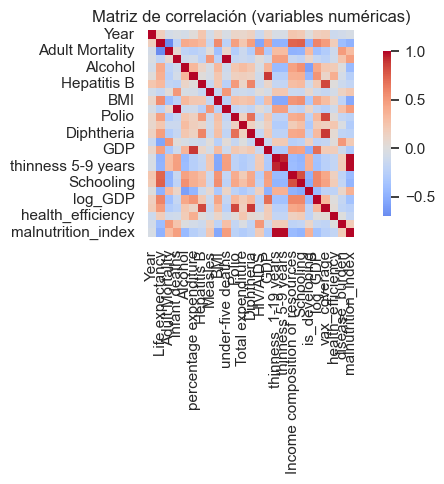

In [33]:
numeric_cols = df.select_dtypes(include=["number"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()



In [34]:
df['GDP'] = df.groupby('Country')['GDP'].transform(
    lambda x: x.where(x >= 0, x.median())
)

In [35]:
mediana_global = df[df['GDP'] > 0]['GDP'].median()
df['GDP'] = df['GDP'].fillna(mediana_global)
df.loc[df['GDP'] < 0, 'GDP'] = mediana_global

In [36]:
df['log_GDP'] = np.log1p(df['GDP'])

In [37]:
df.isna().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
is_developing                      0
log_GDP                            0
vax_coverage                       0
health_efficiency                  0
disease_burden                     0
malnutrition_index                 0
d

In [38]:
numeric_features = [col for col in df.columns if col not in 
            ['Life expectancy', 'Country', 'Year', 'GDP'
             'thinness  1-19 years', 'thinness 5-9 years','Status']]

In [39]:

categorical_features = []  # No categorical features in the current dataset after preprocessing

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

alphas = np.logspace(-4, 2, 30)
l1_ratios = [0.1, 0.5, 0.9, 1.0]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=cv,
    max_iter=20000,
    n_jobs=-1,
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", elastic_cv),
    ]
)

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [40]:
print('Year' in df.columns)

True


In [41]:
año_corte = 2014

In [42]:
df_train = df[df['Year'] <= año_corte].copy()
df_test  = df[df['Year'] > año_corte].copy()

In [43]:
print(f"Train: {df_train.shape}")
print(f"Test:  {df_test.shape}")

Train: (2755, 27)
Test:  (183, 27)


In [44]:
numeric_features

['Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'thinness  1-19 years',
 'Income composition of resources',
 'Schooling',
 'is_developing',
 'log_GDP',
 'vax_coverage',
 'health_efficiency',
 'disease_burden',
 'malnutrition_index']

In [45]:
X_train = df_train[numeric_features]
y_train = df_train['Life expectancy']

X_test = df_test[numeric_features]
y_test = df_test['Life expectancy']


In [46]:
X_train.isna().sum()

Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
thinness  1-19 years               0
Income composition of resources    0
Schooling                          0
is_developing                      0
log_GDP                            0
vax_coverage                       0
health_efficiency                  0
disease_burden                     0
malnutrition_index                 0
dtype: int64

In [47]:
poly_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

poly_model = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=cv,
    max_iter=20000,
    n_jobs=-1,
)

poly_pipe = Pipeline(
    steps=[
        ("preprocess", poly_preprocess),
        ("model", poly_model),
    ]
)

poly_pipe.fit(X_train, y_train)
poly_test_pred = poly_pipe.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.359e+01, tolerance: 2.022e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.057e+01, tolerance: 2.015e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

In [48]:
print(pipe)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Adult Mortality',
                                                   'infant deaths', 'Alcohol',
                                                   'percentage expenditure',
                                                   'Hepatitis B', 'Measles',
                                                   'BMI', 'under-five deaths',
                                                   'Polio', 'Total expenditure',
                                                   'Diphtheria', 'HIV/AIDS',
                                                   'GDP',
                                                   'thinness  1-19 years',
                                                   'Income composition of '
                                                   'resources',
                                                   'Schooling', 'is_developing',


In [49]:
pipe.fit(X_train, y_train)

model = pipe.named_steps["model"]

print("Mejor alpha:", model.alpha_)
print("Mejor l1_ratio:", model.l1_ratio_)


def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

print("MSE train:", mse(y_train, train_pred))
print("MSE test:", mse(y_test, test_pred))
print("RMSE train:", rmse(y_train, train_pred))
print("RMSE test:", rmse(y_test, test_pred))
print("R2 train:", r2_score(y_train, train_pred))
print("R2 test:", r2_score(y_test, test_pred))

Mejor alpha: 0.00016102620275609394
Mejor l1_ratio: 0.1
MSE train: 15.383710350272233
MSE test: 11.725412183243897
RMSE train: 3.9222073313725057
RMSE test: 3.4242389202922006
R2 train: 0.8320589707621415
R2 test: 0.8213514856693709


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.362e+02, tolerance: 2.524e+01
  model = cd_fast.enet_coordinate_descent(


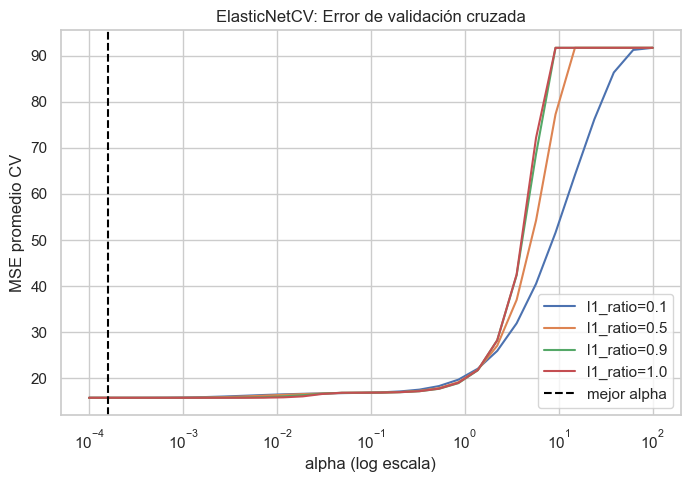

In [50]:
mse_path = model.mse_path_  # shape: (n_l1_ratio, n_alpha, n_folds)
mean_mse = mse_path.mean(axis=2)

l1_ratio_list = model.l1_ratio
if not isinstance(l1_ratio_list, (list, tuple, np.ndarray)):
    l1_ratio_list = [model.l1_ratio_]

plt.figure(figsize=(8, 5))
for i, l1 in enumerate(l1_ratio_list):
    plt.semilogx(model.alphas_, mean_mse[i], label=f"l1_ratio={l1}")

plt.axvline(model.alpha_, color="black", linestyle="--", label="mejor alpha")
plt.xlabel("alpha (log escala)")
plt.ylabel("MSE promedio CV")
plt.title("ElasticNetCV: Error de validación cruzada")
plt.legend()
plt.show()

In [51]:
feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
coefs = model.coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

selected = coef_df[coef_df["abs_coef"] > 1e-6].copy()
print("Variables seleccionadas (coef != 0):", selected.shape[0])

print("Top 20 por |coef|:")
display(selected.sort_values("abs_coef", ascending=False).head(20))

# (Opcional) Re-entrenar sobre variables seleccionadas
preprocessor = pipe.named_steps["preprocess"]
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

selector = SelectFromModel(model, threshold=1e-6, prefit=True)
X_train_sel = selector.transform(X_train_proc)
X_test_sel = selector.transform(X_test_proc)

final_model = ElasticNet(alpha=model.alpha_, l1_ratio=model.l1_ratio_, max_iter=20000)
final_model.fit(X_train_sel, y_train)

train_pred_sel = final_model.predict(X_train_sel)
test_pred_sel = final_model.predict(X_test_sel)

print("RMSE train (selección):", rmse(y_train, train_pred_sel))
print("RMSE test (selección):", rmse(y_test, test_pred_sel))

Variables seleccionadas (coef != 0): 22
Top 20 por |coef|:


,feature,coef,abs_coef
7,num__under-five deaths,-14.907970,14.907970
1,num__infant deaths,14.557179,14.557179
11,num__HIV/AIDS,-2.747880,2.747880
0,num__Adult Mortality,-2.321396,2.321396
15,num__Schooling,2.106109,2.106109
14,num__Income composition of resources,1.179234,1.179234
17,num__log_GDP,1.122079,1.122079
6,num__BMI,0.660241,0.660241
19,num__health_efficiency,0.659765,0.659765
10,num__Diphtheria,0.586628,0.586628


RMSE train (selección): 3.9222073313725057
RMSE test (selección): 3.4242389202922006


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.362e+02, tolerance: 2.524e+01
  model = cd_fast.enet_coordinate_descent(


In [52]:
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

In [53]:
print("Desv. est. de Y (train):", y_train.std())
print("Desv. est. de Y (test):", y_test.std())

if numeric_features:
    X_train_std = X_train[numeric_features].std().sort_values(ascending=False)
    print("Desv. est. de X (train), top 10:")
    display(X_train_std.head(10))

Desv. est. de Y (train): 9.572623444522756
Desv. est. de Y (test): 8.123706147645304
Desv. est. de X (train), top 10:


disease_burden            97283.147050
GDP                       13400.137360
Measles                   11666.714151
percentage expenditure     2043.520542
under-five deaths           163.333915
Adult Mortality             125.617894
infant deaths               119.853868
Hepatitis B                  28.294108
Diphtheria                   24.023109
Polio                        23.598952
dtype: float64

In [54]:
poly_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

poly_model = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=cv,
    max_iter=20000,
    n_jobs=-1,
)

poly_pipe = Pipeline(
    steps=[
        ("preprocess", poly_preprocess),
        ("model", poly_model),
    ]
)

poly_pipe.fit(X_train, y_train)
poly_test_pred = poly_pipe.predict(X_test)

print("MSE test (polinomios):", mse(y_test, poly_test_pred))
print("RMSE test (polinomios):", rmse(y_test, poly_test_pred))

# Selección de variables con Elastic Net y re-entrenamiento
poly_feature_names = poly_pipe.named_steps["preprocess"].get_feature_names_out()
poly_coefs = poly_model.coef_

poly_coef_df = pd.DataFrame({"feature": poly_feature_names, "coef": poly_coefs})
poly_coef_df["abs_coef"] = poly_coef_df["coef"].abs()
selected_poly = poly_coef_df[poly_coef_df["abs_coef"] > 1e-6]

print("Variables seleccionadas (polinomios, coef != 0):", selected_poly.shape[0])
print("Top 20 por |coef| (polinomios):")
display(selected_poly.sort_values("abs_coef", ascending=False).head(20))

poly_preprocessor = poly_pipe.named_steps["preprocess"]
X_train_poly = poly_preprocessor.transform(X_train)
X_test_poly = poly_preprocessor.transform(X_test)

poly_selector = SelectFromModel(poly_model, threshold=1e-6, prefit=True)
X_train_poly_sel = poly_selector.transform(X_train_poly)
X_test_poly_sel = poly_selector.transform(X_test_poly)

poly_final = ElasticNet(alpha=poly_model.alpha_, l1_ratio=poly_model.l1_ratio_, max_iter=20000)
poly_final.fit(X_train_poly_sel, y_train)

poly_train_pred_sel = poly_final.predict(X_train_poly_sel)
poly_test_pred_sel = poly_final.predict(X_test_poly_sel)

print("MSE test (polinomios + selección):", mse(y_test, poly_test_pred_sel))
print("RMSE test (polinomios + selección):", rmse(y_test, poly_test_pred_sel))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.359e+01, tolerance: 2.022e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.057e+01, tolerance: 2.015e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

MSE test (polinomios): 6.0107483971412945
RMSE test (polinomios): 2.4516827684554325
Variables seleccionadas (polinomios, coef != 0): 179
Top 20 por |coef| (polinomios):


,feature,coef,abs_coef
239,num__Income composition of resources^2,8.057646,8.057646
22,num__Adult Mortality^2,-7.287075,7.287075
0,num__Adult Mortality,6.252254,6.252254
107,num__Hepatitis B under-five deaths,-4.068600,4.068600
213,num__HIV/AIDS Schooling,3.919899,3.919899
242,num__Income composition of resources log_GDP,-3.866483,3.866483
33,num__Adult Mortality HIV/AIDS,3.765016,3.765016
214,num__HIV/AIDS is_developing,-3.669021,3.669021
47,num__infant deaths Hepatitis B,3.587262,3.587262
11,num__HIV/AIDS,-3.535112,3.535112


MSE test (polinomios + selección): 6.010003081047701
RMSE test (polinomios + selección): 2.4515307628189578


In [55]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), 
                           param_grid, 
                           cv=5, 
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Mejores params: {grid_search.best_params_}")
print(f"Mejor RMSE CV: {-grid_search.best_score_:.4f}")

Mejores params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Mejor RMSE CV: 2.8495


In [56]:

modelo_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, 
                           max_depth=6, random_state=42)
modelo_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [57]:
y_pred_train = modelo_xgb.predict(X_train)
y_pred_test  = modelo_xgb.predict(X_test)

print("═══ XGBoost ═══")
print(f"\nTRAIN:")
print(f"  R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_train, y_pred_train):.4f}")

print(f"\nTEST:")
print(f"  R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")

═══ XGBoost ═══

TRAIN:
  R²:   0.9955
  RMSE: 0.6445
  MAE:  0.4356

TEST:
  R²:   0.9532
  RMSE: 1.7534
  MAE:  1.1892


In [58]:
param_grid = {
    'n_estimators':    [100, 200, 300, 500],
    'learning_rate':   [0.01, 0.05, 0.1],
    'max_depth':       [3, 5, 6, 8],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor RMSE CV: {-grid_search.best_score_:.4f}")

# Evaluar en test con el mejor modelo
mejor_modelo = grid_search.best_estimator_
y_pred_test  = mejor_modelo.predict(X_test)
y_pred_train = mejor_modelo.predict(X_train)

print("\n═══ XGBoost Optimizado ═══")
print(f"\nTRAIN:")
print(f"  R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")

print(f"\nTEST:")
print(f"  R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}
Mejor RMSE CV: 2.6977

═══ XGBoost Optimizado ═══

TRAIN:
  R²:   0.9903
  RMSE: 0.9440

TEST:
  R²:   0.9492
  RMSE: 1.8255
  MAE:  1.2865


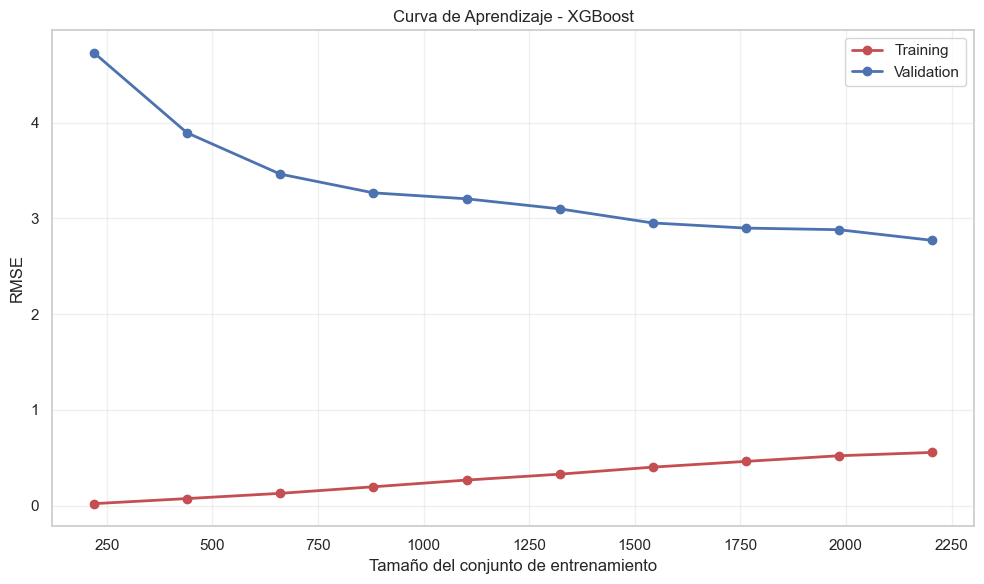

In [59]:
train_sizes, train_scores, val_scores = learning_curve(
    XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Convertir a RMSE positivo
train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, 'r-o', label='Training',   linewidth=2)
plt.plot(train_sizes, val_rmse,   'b-o', label='Validation', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('RMSE')
plt.title('Curva de Aprendizaje - XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

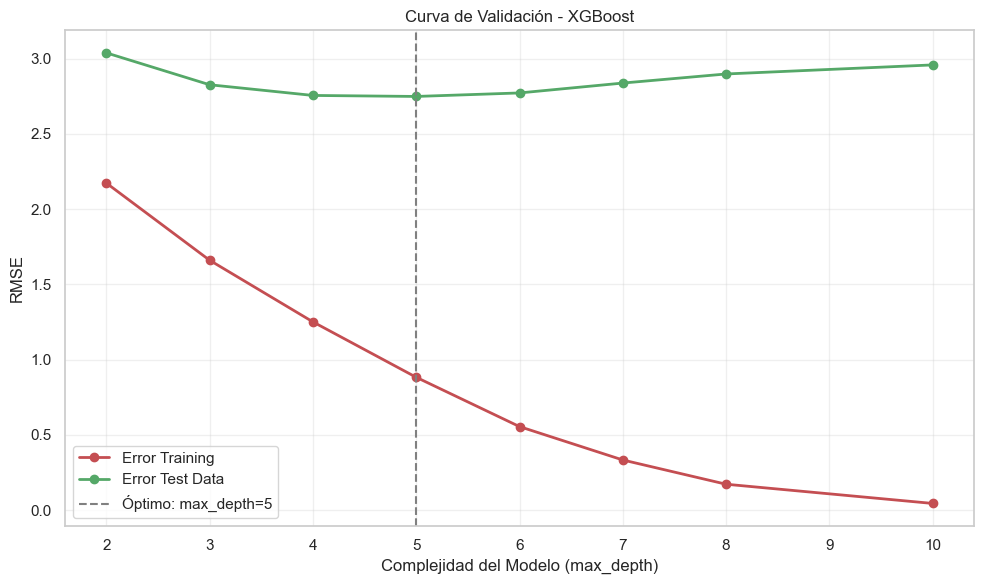

Mejor max_depth: 5 con RMSE validación: 2.7480


In [60]:
param_range = [2, 3, 4, 5, 6, 7, 8, 10]

train_scores, val_scores = validation_curve(
    XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=param_range,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

# Encontrar el óptimo
mejor_idx   = np.argmin(val_rmse)
mejor_depth = param_range[mejor_idx]

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_rmse, 'r-o', label='Error Training', linewidth=2)
plt.plot(param_range, val_rmse,   'g-o', label='Error Test Data', linewidth=2)
plt.axvline(x=mejor_depth, color='gray', linestyle='--', label=f'Óptimo: max_depth={mejor_depth}')
plt.xlabel('Complejidad del Modelo (max_depth)')
plt.ylabel('RMSE')
plt.title('Curva de Validación - XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor max_depth: {mejor_depth} con RMSE validación: {val_rmse[mejor_idx]:.4f}")

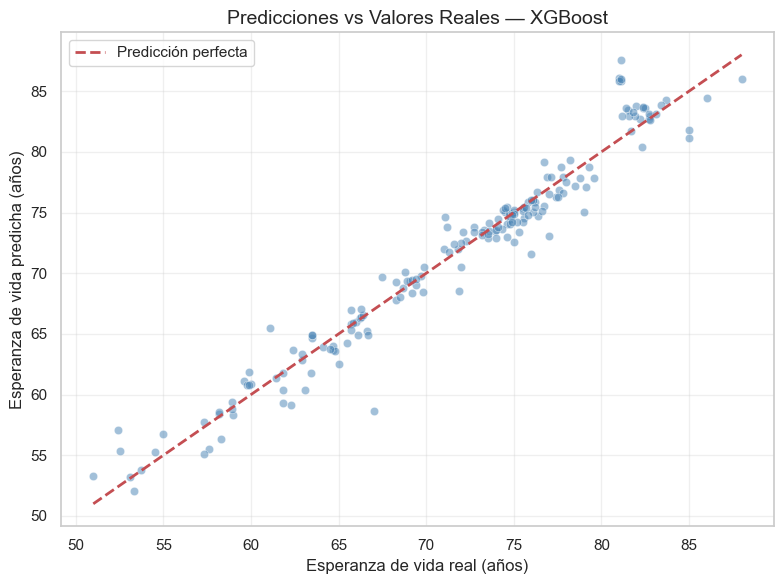

In [61]:
y_pred_test = modelo_xgb.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)

# Línea perfecta
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción perfecta')

plt.xlabel('Esperanza de vida real (años)', fontsize=12)
plt.ylabel('Esperanza de vida predicha (años)', fontsize=12)
plt.title('Predicciones vs Valores Reales — XGBoost', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analisis Residuales XGBOOST (Punto C)

Text(0.5, 1.0, 'Residuals vs Predicted')

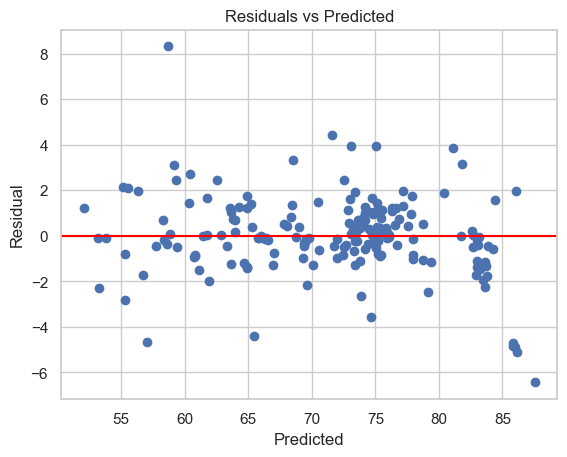

In [62]:
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")

Text(0.5, 1.0, 'Distribution of residuals')

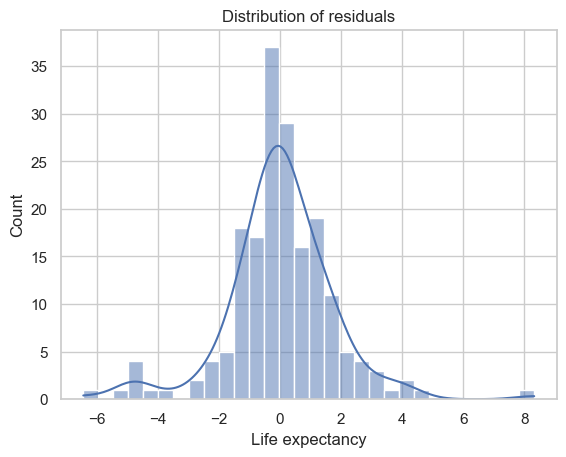

In [63]:
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of residuals")

In [64]:
df_res = pd.DataFrame({
    "Country": df_test["Country"],
    "error": abs(residuals)
})

df_res.groupby("Country")["error"].mean().sort_values(ascending=False).head(10)

Country
Zimbabwe                                 8.317596
Belgium                                  6.437392
Germany                                  5.106262
Portugal                                 4.900412
Greece                                   4.858551
Finland                                  4.720496
Angola                                   4.662332
Democratic People's Republic of Korea    4.411362
Gambia                                   4.391020
Bolivia (Plurinational State of)         3.949615
Name: error, dtype: float64

## Interpretación economica

### Importancia de las variables

El modelo seleccionado (XGBoost) identifica como variables más influyentes para predecir
la esperanza de vida las siguientes:

1. Disease burden
2. HIV/AIDS
3. Income composition of resources
4. Adult mortality
5. Schooling
6. Malnutrition index

La variable con mayor importancia es disease burden, que captura la carga de enfermedad
combinando indicadores de mortalidad y enfermedades infecciosas. Esto es consistente con
la literatura en salud pública y desarrollo económico: países con mayor incidencia de
enfermedades graves tienden a presentar menor esperanza de vida debido al impacto directo
sobre la mortalidad.

La segunda variable más relevante es HIV/AIDS, lo cual también es esperable. La
prevalencia del VIH ha sido históricamente uno de los determinantes más importantes de la
mortalidad en países en desarrollo, especialmente en África subsahariana, donde epidemias
prolongadas han reducido significativamente la esperanza de vida.

En tercer lugar, aparece Income composition of resources, que mide el nivel de desarrollo
económico y la capacidad de los hogares para acceder a bienes y servicios. Economías con
mayor ingreso y mejor distribución de recursos suelen tener mejores condiciones sanitarias,
acceso a nutrición adecuada y mayor cobertura de servicios médicos, lo cual contribuye a
una mayor longevidad.

La variable Adult mortality también resulta altamente relevante. Este indicador refleja
directamente las condiciones sanitarias y la prevalencia de enfermedades en la población
adulta. Altos niveles de mortalidad adulta suelen estar asociados con sistemas de salud
débiles, enfermedades infecciosas o condiciones socioeconómicas adversas.

Finalmente, Schooling aparece como un determinante importante. La educación está
fuertemente relacionada con mejores resultados de salud, ya que poblaciones más educadas
tienden a adoptar comportamientos preventivos, tener mayor acceso a información sanitaria
y utilizar más eficientemente los servicios de salud.

En conjunto, estas variables reflejan que la esperanza de vida depende principalmente de tres
dimensiones estructurales: la carga de enfermedad, el desarrollo económico y el capital
humano.

#### Ejercicio contrafactual

Para ilustrar cómo cambios en variables de política pública podrían afectar la esperanza de
vida predicha por el modelo, se realizó un ejercicio contrafactual utilizando la variable
health_efficiency, definida como la proporción del gasto en salud respecto al PIB del país.
Esta variable captura de manera aproximada la importancia relativa del gasto sanitario dentro
de la economía.

 En el ejercicio se simuló un escenario en el que la eficiencia del gasto en salud se duplica,
manteniendo constantes las demás variables del país analizado. Bajo este escenario, el
modelo predice un aumento aproximado de 0.42 años en la esperanza de vida.

Este resultado sugiere que mayores recursos destinados al sistema de salud, en relación con
el tamaño de la economía, pueden asociarse con mejoras moderadas en los resultados de
salud de la población. Desde una perspectiva de política pública, esto es consistente con la
literatura en economía del desarrollo, que destaca la importancia del financiamiento
adecuado de los sistemas de salud para mejorar la longevidad y reducir la mortalidad.

Sin embargo, este ejercicio debe interpretarse con cautela. El modelo utilizado es un modelo
predictivo basado en árboles de decisión (XGBoost), por lo que el resultado refleja
únicamente cómo el modelo relaciona estas variables dentro de los datos observados. En
consecuencia, el ejercicio no debe interpretarse como una estimación causal del efecto del
gasto en salud sobre la esperanza de vida, sino como una simulación ilustrativa del
comportamiento del modelo ante cambios en variables relevantes de política pública.

#### Países con mayores errores de predicción

El análisis de errores del modelo permite identificar países donde las predicciones son menos
precisas. Los países con mayor error absoluto promedio incluyen:

• Zimbabwe
• Bélgica
• Finlandia
• Angola
• Grecia

Estos resultados muestran dos patrones distintos.

Por un lado, aparecen países como Zimbabwe y Angola, caracterizados por niveles
relativamente bajos de esperanza de vida, alta mortalidad adulta y elevada prevalencia de
enfermedades infecciosas. Por ejemplo, Zimbabwe presenta una esperanza de vida promedio
cercana a 50 años y una prevalencia de VIH significativamente mayor que otros países. En
estos contextos, shocks sanitarios y crisis institucionales pueden generar dinámicas
complejas que el modelo no captura completamente.

Por otro lado, también aparecen países desarrollados como Bélgica y Finlandia, donde la
esperanza de vida es muy alta (alrededor de 80 años). En estos casos, pequeñas variaciones
en factores como envejecimiento poblacional, enfermedades crónicas o calidad del sistema de salud pueden producir diferencias en longevidad difíciles de explicar únicamente con
variables macroeconómicas y sanitarias agregadas.
Estos resultados sugieren que el modelo presenta mayor dificultad para predecir
correctamente países en dos extremos del espectro: economías con crisis sanitarias severas y
economías altamente desarrolladas donde pequeñas diferencias institucionales generan
variaciones relevantes en los resultados de salud.


In [65]:
importances = modelo_xgb.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

feat_imp.head(10)

disease_burden                     0.618484
HIV/AIDS                           0.196333
Income composition of resources    0.086030
Adult Mortality                    0.021682
Schooling                          0.021172
malnutrition_index                 0.007103
thinness  1-19 years               0.006021
infant deaths                      0.005815
under-five deaths                  0.005332
Alcohol                            0.003825
dtype: float32

In [66]:
pais = X_test.iloc[[0]].copy()

pais_cf = pais.copy()
pais_cf["percentage expenditure"] = pais_cf["percentage expenditure"] * 2

pred_original = modelo_xgb.predict(pais)
pred_cf = modelo_xgb.predict(pais_cf)

pred_cf - pred_original

array([0.], dtype=float32)

In [67]:
pais = X_test.iloc[[0]].copy()

pais_cf = pais.copy()
pais_cf["health_efficiency"] = pais_cf["health_efficiency"] * 2

pred_original = modelo_xgb.predict(pais)
pred_cf = modelo_xgb.predict(pais_cf)

pred_cf - pred_original

array([0.26366043], dtype=float32)

In [68]:
y_pred_test = modelo_xgb.predict(X_test)

df_res = pd.DataFrame({
    "Country": df_test["Country"],
    "Year": df_test["Year"],
    "y_real": y_test,
    "y_pred": y_pred_test
})

df_res["residual"] = df_res["y_real"] - df_res["y_pred"]
df_res["abs_error"] = abs(df_res["residual"])

In [69]:
errores_pais = (
    df_res.groupby("Country")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

errores_pais.head(10)

Country
Zimbabwe                                 8.317596
Belgium                                  6.437392
Germany                                  5.106262
Portugal                                 4.900412
Greece                                   4.858551
Finland                                  4.720496
Angola                                   4.662332
Democratic People's Republic of Korea    4.411362
Gambia                                   4.391020
Bolivia (Plurinational State of)         3.949615
Name: abs_error, dtype: float64

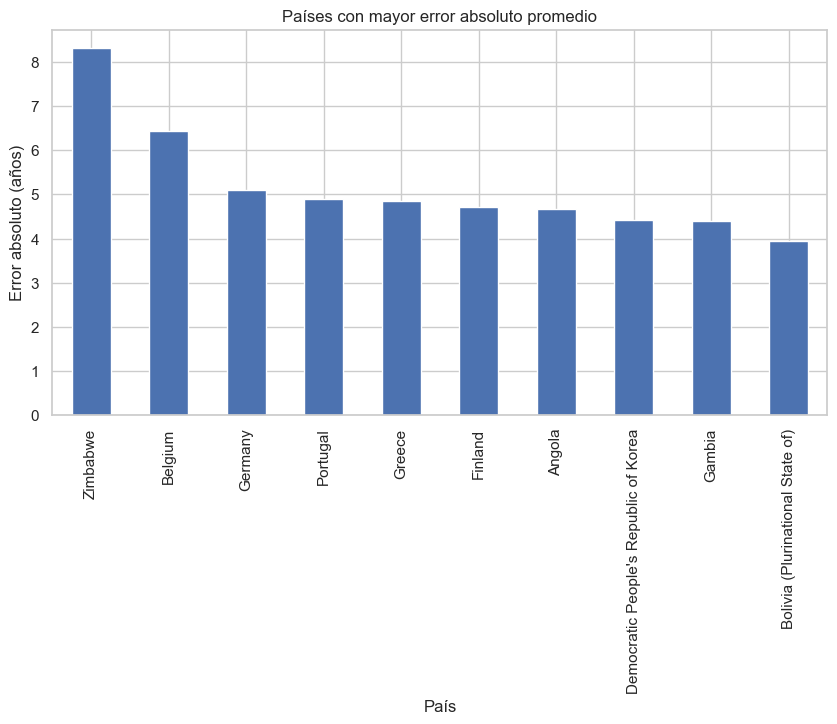

In [70]:
errores_pais.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Países con mayor error absoluto promedio")
plt.ylabel("Error absoluto (años)")
plt.xlabel("País")
plt.show()

In [71]:
top_paises = errores_pais.head(5).index
top_paises

Index(['Zimbabwe', 'Belgium', 'Germany', 'Portugal', 'Greece'], dtype='str', name='Country')

In [72]:
df[df["Country"].isin(top_paises)][[
    "Country",
    "Life expectancy",
    "Adult Mortality",
    "HIV/AIDS",
    "Schooling",
    "GDP"
]].groupby("Country").mean()

,Life expectancy,Adult Mortality,HIV/AIDS,Schooling,GDP
Country,,,,,
Belgium,80.68125,70.1875,0.1000,16.7875,16915.306000
Germany,81.17500,71.2500,0.1000,16.6000,24337.749100
Greece,81.21875,73.6250,0.1000,15.9375,16454.235870
Portugal,79.99375,58.8750,0.1000,15.9375,11598.625531
Zimbabwe,50.48750,462.3750,23.2625,9.8250,410.980194


## Exportación modelo

In [74]:
joblib.dump(modelo_xgb, 'modelo_xgboost_esperanza_vida.pkl')
print("Modelo exportado con joblib: modelo_xgboost_esperanza_vida.pkl")

Modelo exportado con joblib: modelo_xgboost_esperanza_vida.pkl


In [76]:
modelo_cargado_xgb = joblib.load('modelo_xgboost_esperanza_vida.pkl')
y_pred_verificacion = modelo_cargado_xgb.predict(X_test)

print(f"\nVerificación modelo cargado:")
print(f"  R²:   {r2_score(y_test, y_pred_verificacion):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_verificacion)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_verificacion):.4f}")


Verificación modelo cargado:
  R²:   0.9532
  RMSE: 1.7534
  MAE:  1.1892
